<a href="https://colab.research.google.com/github/mwakitrevor146-prog/semi-conductor-factor-model/blob/main/1_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.makedirs("semiconductor-factor-model/data", exist_ok=True)
os.makedirs("semiconductor-factor-model/notebooks", exist_ok=True)
os.makedirs("semiconductor-factor-model/src", exist_ok=True)
os.makedirs("semiconductor-factor-model/visuals", exist_ok=True)
os.makedirs("semiconductor-factor-model/reports", exist_ok=True)

im going to build a clean dataset for:

prices
returns
volatility
momentum

for key semiconductor stocks

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
tickers = [
    "NVDA",  # AI compute
    "AMD",   # GPU/CPU competitor
    "TSM",   # Foundry
    "ASML",  # Lithography equipment
    "AVGO",  # Broadcom (AI + networking)
    "MU",    # Memory
    "MRVL"   # Networking / AI infra
]

In [ ]:
#download price data
data = yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]

/tmp/ipykernel_6147/750835618.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  7 of 7 completed


In [ ]:
#clean data
data = data.dropna()
data.head()

Ticker,AMD,ASML,AVGO,MRVL,MU,NVDA,TSM
Date,,,,,,,
2020-01-02,49.099998,285.900787,27.677492,26.634502,54.021156,5.970754,53.628567
2020-01-03,48.599998,281.293640,26.973518,25.943838,53.182400,5.875187,51.860001
2020-01-06,48.389999,279.056122,26.933167,24.980793,52.246132,5.899825,51.261551
2020-01-07,48.250000,282.086639,26.840450,25.535273,56.829983,5.971253,52.092236
2020-01-08,47.830002,285.013336,26.505629,25.340717,56.098518,5.982452,52.476318


In [ ]:
#daily returns
returns = data.pct_change().dropna()
returns.head()

Ticker,AMD,ASML,AVGO,MRVL,MU,NVDA,TSM
Date,,,,,,,
2020-01-03,-0.010183,-0.016114,-0.025435,-0.025931,-0.015526,-0.016006,-0.032978
2020-01-06,-0.004321,-0.007954,-0.001496,-0.037120,-0.017605,0.004194,-0.011540
2020-01-07,-0.002893,0.010860,-0.003442,0.022196,0.087736,0.012107,0.016205
2020-01-08,-0.008705,0.010375,-0.012475,-0.007619,-0.012871,0.001875,0.007373
2020-01-09,0.023834,-0.001689,-0.008033,0.001919,-0.003651,0.010983,0.008170


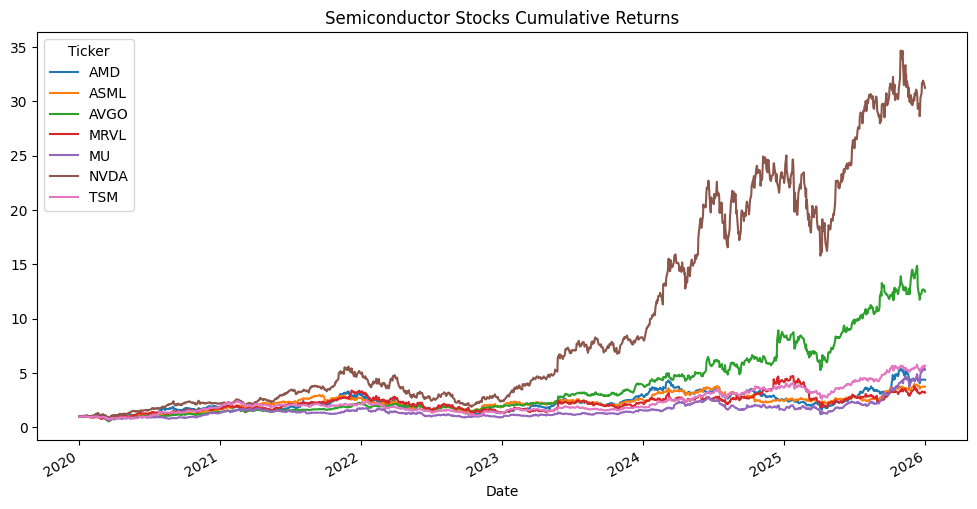

In [ ]:
#cummulative returns
cumulative = (1 + returns).cumprod()

cumulative.plot(figsize=(12,6))
plt.title("Semiconductor Stocks Cumulative Returns")
plt.show()

In [ ]:
#volatility (risk metric)
volatility = returns.std() * np.sqrt(252)
volatility.sort_values(ascending=False)

,0
Ticker,
MRVL,0.573769
AMD,0.538852
NVDA,0.531849
MU,0.500979
AVGO,0.439220
ASML,0.428816
TSM,0.388617


In [ ]:
#momentum
momentum = (data.iloc[-1] / data.iloc[-126]) - 1
momentum.sort_values(ascending=False)

,0
Ticker,
MU,1.338483
AMD,0.552897
ASML,0.352393
TSM,0.301839
AVGO,0.262288
NVDA,0.170584
MRVL,0.132028


In [ ]:
factor_df = pd.DataFrame({
    "Momentum": momentum,
    "Volatility": volatility
})

factor_df

,Momentum,Volatility
Ticker,,
AMD,0.552897,0.538852
ASML,0.352393,0.428816
AVGO,0.262288,0.439220
MRVL,0.132028,0.573769
MU,1.338483,0.500979
NVDA,0.170584,0.531849
TSM,0.301839,0.388617


In [ ]:
#score
factor_df["Momentum_Score"] = factor_df["Momentum"].rank(pct=True)
factor_df["Volatility_Score"] = 1 - factor_df["Volatility"].rank(pct=True)

In [ ]:
factor_df["Final_Score"] = (
    0.6 * factor_df["Momentum_Score"] +
    0.4 * factor_df["Volatility_Score"]
)

In [ ]:
#rank
factor_df.sort_values("Final_Score", ascending=False)

,Momentum,Volatility,Momentum_Score,Volatility_Score,Final_Score
Ticker,,,,,
MU,1.338483,0.500979,1.000000,0.428571,0.771429
ASML,0.352393,0.428816,0.714286,0.714286,0.714286
TSM,0.301839,0.388617,0.571429,0.857143,0.685714
AMD,0.552897,0.538852,0.857143,0.142857,0.571429
AVGO,0.262288,0.439220,0.428571,0.571429,0.485714
NVDA,0.170584,0.531849,0.285714,0.285714,0.285714
MRVL,0.132028,0.573769,0.142857,0.000000,0.085714


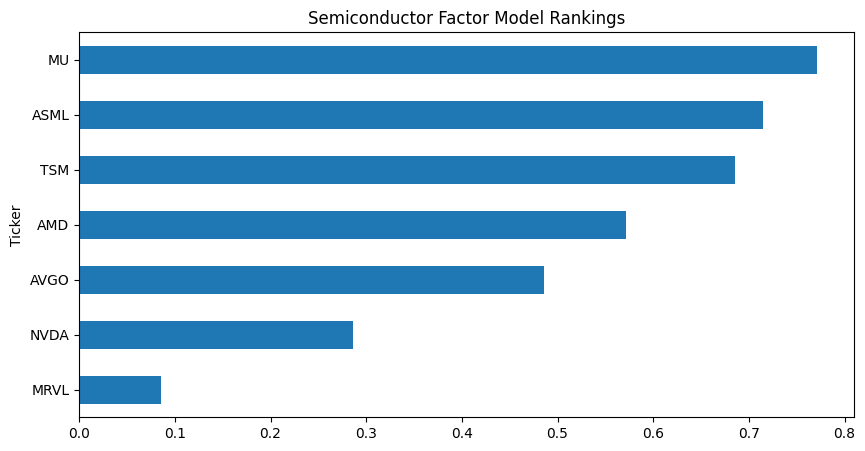

In [ ]:
factor_df["Final_Score"].sort_values().plot(kind="barh", figsize=(10,5))
plt.title("Semiconductor Factor Model Rankings")
plt.show()

| Factor           | Meaning                   |
| ---------------- | ------------------------- |
| Revenue Growth   | Is the company scaling?   |
| Profitability    | Gross margin strength     |
| Valuation        | Is it expensive or cheap? |
| Financial Health | Balance sheet strength    |


In [ ]:
tickers = ["NVDA", "AMD", "TSM", "ASML", "AVGO", "MU", "MRVL"]

In [ ]:
import yfinance as yf

fundamentals = []

for t in tickers:
    stock = yf.Ticker(t)
    info = stock.info

    fundamentals.append({
        "Ticker": t,
        "RevenueGrowth": info.get("revenueGrowth", np.nan),
        "GrossMargin": info.get("grossMargins", np.nan),
        "PE": info.get("trailingPE", np.nan),
        "DebtToEquity": info.get("debtToEquity", np.nan),
        "ProfitMargin": info.get("profitMargins", np.nan)
    })

fund_df = pd.DataFrame(fundamentals)
fund_df

,Ticker,RevenueGrowth,GrossMargin,PE,DebtToEquity,ProfitMargin
0,NVDA,0.732,0.71068,44.784115,7.255,0.55603
1,AMD,0.378,0.53060,154.523330,6.005,0.13374
2,TSM,0.351,0.61873,34.557180,17.131,0.46505
3,ASML,0.132,0.52603,51.399376,12.989,0.29713
4,AVGO,0.295,0.76726,83.651375,82.704,0.36572
5,MU,1.963,0.58437,38.022163,14.902,0.41486
6,MRVL,0.221,0.51024,55.563725,33.479,0.32584


In [ ]:
fund_df = fund_df.replace([np.inf, -np.inf], np.nan).dropna()
fund_df

,Ticker,RevenueGrowth,GrossMargin,PE,DebtToEquity,ProfitMargin
0,NVDA,0.732,0.71068,44.784115,7.255,0.55603
1,AMD,0.378,0.53060,154.523330,6.005,0.13374
2,TSM,0.351,0.61873,34.557180,17.131,0.46505
3,ASML,0.132,0.52603,51.399376,12.989,0.29713
4,AVGO,0.295,0.76726,83.651375,82.704,0.36572
5,MU,1.963,0.58437,38.022163,14.902,0.41486
6,MRVL,0.221,0.51024,55.563725,33.479,0.32584


In [ ]:
#revenue growth score
fund_df["RG_Score"] = (
    (fund_df["RevenueGrowth"] - fund_df["RevenueGrowth"].min()) /
    (fund_df["RevenueGrowth"].max() - fund_df["RevenueGrowth"].min())
)

In [ ]:
#profitability score
fund_df["Margin_Score"] = (
    (fund_df["GrossMargin"] - fund_df["GrossMargin"].min()) /
    (fund_df["GrossMargin"].max() - fund_df["GrossMargin"].min())
)

In [ ]:
#valuation score
fund_df["PE_Score"] = 1 - (
    (fund_df["PE"] - fund_df["PE"].min()) /
    (fund_df["PE"].max() - fund_df["PE"].min())
)

In [ ]:
#debt risk score
fund_df["Debt_Score"] = 1 - (
    (fund_df["DebtToEquity"] - fund_df["DebtToEquity"].min()) /
    (fund_df["DebtToEquity"].max() - fund_df["DebtToEquity"].min())
)

In [ ]:
fund_df["Fundamental_Score"] = (
    0.30 * fund_df["RG_Score"] +
    0.30 * fund_df["Margin_Score"] +
    0.20 * fund_df["PE_Score"] +
    0.20 * fund_df["Debt_Score"]
)

In [ ]:
#merge
final_df = factor_df.merge(fund_df, left_index=True, right_on="Ticker")

In [ ]:
final_df["Total_Score"] = (
    0.45 * final_df["Final_Score"] +      # momentum/risk
    0.55 * final_df["Fundamental_Score"]  # fundamentals
)

In [ ]:
final_df.sort_values("Total_Score", ascending=False)[
    ["Ticker", "Total_Score", "Fundamental_Score"]
]

,Ticker,Total_Score,Fundamental_Score
5,MU,0.763795,0.757550
2,TSM,0.601998,0.533502
3,ASML,0.526106,0.372141
0,NVDA,0.520147,0.711956
4,AVGO,0.463244,0.444860
1,AMD,0.402382,0.264071
6,MRVL,0.207928,0.307920


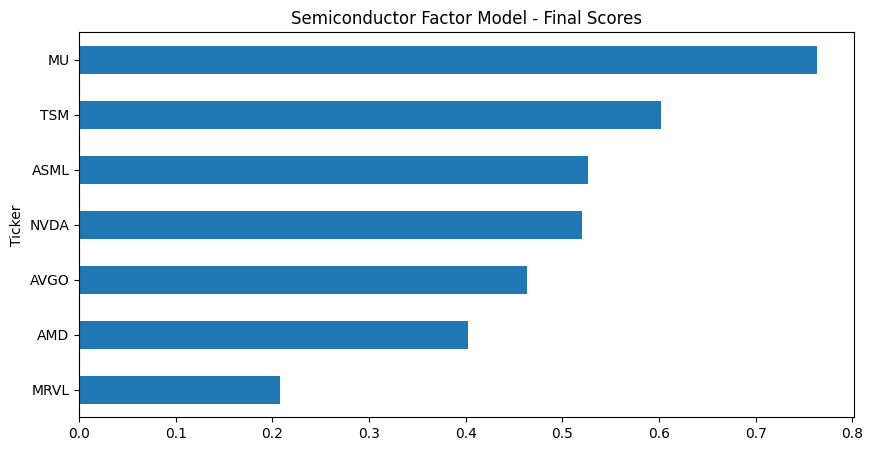

In [ ]:
final_df.set_index("Ticker")["Total_Score"].sort_values().plot(kind="barh", figsize=(10,5))
plt.title("Semiconductor Factor Model - Final Scores")
plt.show()

In [ ]:
top_picks = final_df.sort_values("Total_Score", ascending=False).head(3)
top_picks

,Momentum,Volatility,Momentum_Score,Volatility_Score,Final_Score,Ticker,RevenueGrowth,GrossMargin,PE,DebtToEquity,ProfitMargin,RG_Score,Margin_Score,PE_Score,Debt_Score,Fundamental_Score,Total_Score
5,1.338483,0.500979,1.000000,0.428571,0.771429,MU,1.963,0.58437,38.022163,14.902,0.41486,1.000000,0.288421,0.971117,0.884001,0.757550,0.763795
2,0.301839,0.388617,0.571429,0.857143,0.685714,TSM,0.351,0.61873,34.557180,17.131,0.46505,0.119607,0.422107,1.000000,0.854939,0.533502,0.601998
3,0.352393,0.428816,0.714286,0.714286,0.714286,ASML,0.132,0.52603,51.399376,12.989,0.29713,0.000000,0.061435,0.859609,0.908943,0.372141,0.526106


In [ ]:
portfolio_tickers = top_picks["Ticker"].tolist()

In [ ]:
portfolio_returns = returns[portfolio_tickers].mean(axis=1)
cumulative_portfolio = (1 + portfolio_returns).cumprod()

In [ ]:
soxx = yf.download("SOXX", start="2020-01-01", end="2026-01-01")["Close"]
soxx_returns = soxx.pct_change().dropna()
cumulative_soxx = (1 + soxx_returns).cumprod()

/tmp/ipykernel_6147/3208938716.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  soxx = yf.download("SOXX", start="2020-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed


In [ ]:
#sharpe ratio
risk_free = 0.02

sharpe = (portfolio_returns.mean() * 252 - risk_free) / (portfolio_returns.std() * np.sqrt(252))
sharpe

np.float64(0.8799972461961163)

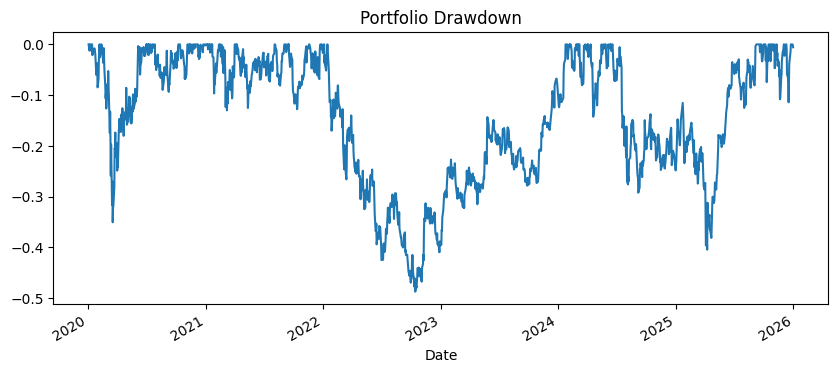

In [ ]:
drawdown = cumulative_portfolio / cumulative_portfolio.cummax() - 1

drawdown.plot(figsize=(10,4))
plt.title("Portfolio Drawdown")
plt.show()

A simple app that lets someone:


semiconductor stock rankings
factor scores
charts

In [ ]:
The application file will be located at: `dashboard/app.py`

SyntaxError: invalid syntax (963811043.py, line 1)

In [ ]:
import os
os.makedirs('dashboard', exist_ok=True)

In [59]:
%%writefile dashboard/app.py

import streamlit as st
import pandas as pd
import yfinance as yf
import numpy as np

st.set_page_config(layout="wide")
st.title("Semiconductor Stock Dashboard")

# Load data
# Adjust path assuming app.py is in 'dashboard' and data is in 'semiconductor-factor-model/data'
try:
    df = pd.read_csv("../semiconductor-factor-model/data/final_factor_model.csv")
except FileNotFoundError:
    st.error("Error: final_factor_model.csv not found. Make sure it's in the 'semiconductor-factor-model/data' directory relative to the app.")
    st.stop()

st.header("Stock Rankings")
# Display stock rankings
top_stocks = df.sort_values("Total_Score", ascending=False)[["Ticker", "Total_Score"]]
st.write(top_stocks)

st.header("Factor Scores")
# Display factor scores
st.bar_chart(df.set_index("Ticker")["Total_Score"])

st.header("Portfolio Performance vs SOXX")
# Re-calculate portfolio performance within Streamlit app
# This part assumes yfinance is installed in the Streamlit environment
tickers_for_portfolio = df.sort_values("Total_Score", ascending=False).head(3)["Ticker"].tolist()

@st.cache_data # Cache data to avoid re-downloading on every rerun
def get_historical_data(tickers_list, start_date="2020-01-01"):
    return yf.download(tickers_list, start=start_date)["Close"]

data_yf = get_historical_data(tickers_for_portfolio + ["SOXX"])

if not data_yf.empty:
    returns_yf = data_yf.pct_change().dropna()

    valid_portfolio_tickers = [t for t in tickers_for_portfolio if t in returns_yf.columns]
    if valid_portfolio_tickers:
        portfolio_returns_mean = returns_yf[valid_portfolio_tickers].mean(axis=1)
        portfolio_perf = (portfolio_returns_mean + 1).cumprod()
    else:
        portfolio_perf = pd.Series([], dtype='float64') # Empty series if no valid tickers

    if "SOXX" in returns_yf.columns:
        benchmark_perf = (returns_yf["SOXX"] + 1).cumprod()
    else:
        benchmark_perf = pd.Series([], dtype='float64') # Empty series if SOXX not found

    plot_df = pd.DataFrame()
    if not portfolio_perf.empty:
        plot_df["Model Portfolio"] = portfolio_perf
    if not benchmark_perf.empty:
        plot_df["SOXX ETF"] = benchmark_perf

    if not plot_df.empty:
        st.line_chart(plot_df)
    else:
        st.write("Could not generate portfolio performance chart due to missing data.")
else:
    st.write("Could not download historical data for portfolio performance.")


Overwriting dashboard/app.py


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 80.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import yfinance as yf

st.title("Semiconductor Factor Model Dashboard")

2026-05-11 19:48:02.500 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:48:02.722 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-11 19:48:02.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:48:02.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
final_df.to_csv("semiconductor-factor-model/data/final_factor_model.csv")

In [ ]:
st.header("Top Semiconductor Stocks")

top = final_df.sort_values("Total_Score", ascending=False).head(5)
st.write(top[["Ticker", "Total_Score"]])

2026-05-11 19:50:27.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:50:27.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:50:27.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:50:27.501 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:50:27.502 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:50:27.503 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
st.header("Factor Scores")

st.bar_chart(final_df.set_index("Ticker")["Total_Score"])

2026-05-11 19:51:23.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:23.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:23.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:25.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:25.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:25.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
st.header("Portfolio Performance vs SOXX")

2026-05-11 19:51:50.103 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:50.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:51:50.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
import numpy as np

tickers = top["Ticker"].tolist()
data = yf.download(tickers + ["SOXX"], start="2020-01-01")["Close"]

returns = data.pct_change().dropna()

portfolio = returns[tickers].mean(axis=1).cumprod()
benchmark = returns["SOXX"].cumprod()

st.line_chart(pd.DataFrame({
    "Model Portfolio": portfolio,
    "SOXX ETF": benchmark
}))

/tmp/ipykernel_6147/3536417032.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + ["SOXX"], start="2020-01-01")["Close"]
[*********************100%***********************]  6 of 6 completed
2026-05-11 19:52:40.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:52:40.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 19:52:40.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [53]:
!streamlit run dashboard/app.py



2026-05-11 19:53:55.773 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.114.30.238:8501

  Stopping...


In [55]:
app_code = """
import streamlit as st
import pandas as pd
import yfinance as yf

st.title('Semiconductor Factor Model Dashboard')

st.write('Dashboard is running successfully!')
"""

with open("app.py", "w") as f:
    f.write(app_code)

In [56]:
final_df.to_csv("final_factor_model.csv", index=False)

In [58]:
!git add .
!git commit -m "Add Streamlit app and dataset"
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
